In [1]:
import Pkg
Pkg.activate(joinpath(@__DIR__, "..", "..", ".."))  # activate docs/

  Activating project at `~/Documents/Uni/Courses/26_HTN/Qritical.jl/docs`


> **Why activate `docs/` and not the root project?**
>
> The `docs/` directory has its own `Project.toml` that lists documentation-specific
> dependencies — `Documenter.jl`, `Literate.jl`, `CairoMakie.jl` for inline plots,
> `BenchmarkTools.jl`, and so on. The root `Qritical.jl` project only declares the
> *library's* runtime dependencies (the things a downstream user of Qritical would need),
> so activating it here would mean `using CairoMakie` blows up with a
> "not found in current active environment" error.
>
> **Does this survive a GitHub Pages build?** Yes. When Documenter.jl runs in CI
> (via `docs/make.jl`), it activates the same `docs/` environment before processing any
> notebooks or Literate scripts. The `@__DIR__` macro expands to the *source location of
> the file being evaluated at runtime*, so it correctly resolves to `docs/` both on your
> local machine and inside the CI runner — your absolute local path never leaks into the
> build artefacts.

In [2]:
using LinearAlgebra, DelimitedFiles, Serialization, Qritical
using CairoMakie, BenchmarkTools
using InteractiveUtils   # versioninfo() (auto-loaded by IJulia, explicit for scripts/docs)

DATA_ROOT = normpath(joinpath(@__DIR__, "..", "..", "..", "..", "data"))

"/Users/bavithra/Documents/Uni/Courses/26_HTN/Qritical.jl/data"

# Ex 1. SVD Basics

## (a) Julia install party

Verify the Julia environment and that Qritical is loaded correctly.

In [3]:
versioninfo()
println("Qritical loaded: ", Qritical)

Julia Version 1.12.6
Commit 15346901f00 (2026-04-09 19:20 UTC)
Build Info:
  Official https://julialang.org release
Platform Info:
  OS: macOS (arm64-apple-darwin24.0.0)
  CPU: 10 × Apple M1 Pro
  WORD_SIZE: 64
  LLVM: libLLVM-18.1.7 (ORCJIT, apple-m1)
  GC: Built with stock GC
Threads: 1 default, 1 interactive, 1 GC (on 8 virtual cores)
Qritical loaded: Qritical


## (b) SVD a matrix — `A.txt`

```mermaid
flowchart LR
    A["📂 Load A.txt\nraw Julia Matrix"] --> B["🏷️ Wrap in QTensor\nwith named legs i↑ and j↓"]
    B --> C["✂️ Define Bipartition\ni on the left  ·  j on the right"]
    C --> D["⚙️ do_svd\nValCutoffTrunc(1e-3)"]
    D --> E["📊 U, Σ, Vd\n+ Schmidt rank r\n+ truncation error ε"]
```

Load the $64 \times 64$ matrix, wrap it in a `QTensor` with named upper/lower indices,
then call `do_svd` with `ValCutoffTrunc(1e-3)` to find the Schmidt rank when
singular values below $10^{-3}$ are discarded.

In [4]:
A_mat = readdlm(joinpath(DATA_ROOT, "A.txt"))
println("Shape: ", size(A_mat), "  eltype: ", eltype(A_mat))

# get the number of rows and columns from the shape of the loaded array so that a leg with the correct local dimensions can be created
nrows, ncols =  size(A_mat);

i_row = upper(:i, nrows);
j_col = lower(:j, ncols);

@show i_row, j_col;


Shape: (64, 64)  eltype: Float64
(i_row, j_col) = (TIx{Upper}(:i, 64), TIx{Lower}(:j, 64))


### What exactly is a `QTensor`?

A `QTensor` is, at its core, a physics-flavoured wrapper around a plain Julia array.
Think of it as a named-index tensor in the sense that tensor network practitioners use
the word — a multidimensional array where each axis (called a **leg**) is tagged with
a name and a direction.

The two flavours of direction are:
- **Upper** — created with `upper(:name, dim)`, conventionally drawn as an upward-pointing
  index in Penrose notation, playing the role of a "ket" or "column" space
- **Lower** — created with `lower(:name, dim)`, playing the role of a "bra" or "row" space

If you're now reaching for your general relativity textbook thinking "covariant
transformation laws, cotangent bundles, pullbacks..." — you can put it back on the shelf.
In quantum mechanics everything lives in a finite-dimensional Hilbert space equipped with
the trivial inner product (the Kronecker delta), which means the distinction between
upper and lower indices reduces to a bookkeeping convention to track which legs belong to
ket spaces and which to bra spaces. The full differential-geometry machinery — transformation
properties, differentiability, bundles — is overkill here and simply isn't implemented.

What Qritical *does* give you by naming legs:

1. **Legibility** — contraction expressions read like physics equations, not a soup of
   integer axis indices
2. **Partition safety** — `do_svd` knows which legs to group as "row-like" vs "column-like"
   without you manually reshaping anything
3. **Early error detection** — mismatched index names produce an error at the contraction
   site, not a wrong-but-silent result pages later

Under the hood the backing storage is a plain `Array{T,N}`, accessible via `.data`, so
every Julia linear algebra and broadcasting primitive still works when you need to drop
down to the raw array.

In [5]:
# create a QTensor object with the index legs
A   = QTensor(A_mat, (i_row, j_col));

### Bipartitions for a matrix — and why we keep it simple here

To run `do_svd`, Qritical needs to know *how to fold the tensor into a matrix*:
which legs pile up on the left (the "row block") and which go on the right
(the "column block"). This grouping is called a **bipartition**.

For a rank-2 tensor — an ordinary matrix — this is completely trivial: there is only
one leg on each side. We write `bipartition(Partition([i_row]), A)` to declare that
all legs in the left partition go to the "row" side, with everything else automatically
landing on the "column" side.

We're deliberately *not* pulling out the full `Partition` machinery of Qritical here.
The case where it really earns its keep is when you have a **higher-rank tensor** —
like the 10-qubit quantum state `ψ` in part (c), which has 10 legs — where there is
no single obvious "matrix view". There you must explicitly decide which *subset* of legs
to group together, and the `Partition` type manages all the necessary reshaping under the
hood. That's coming up in part (c).

In [6]:
bp  = bipartition(Partition([i_row]), A)

Bipartition(AbstractIx[TIx{Upper}(:i, 64)], AbstractIx[TIx{Lower}(:j, 64)])

### Truncating small singular values — a floating-point reality check

In exact arithmetic the SVD factorisation is perfect and `U Σ Vᵀ` reconstructs `A`
without any error. In floating-point land, nothing is exact.

Matrix elements are stored as 64-bit IEEE 754 doubles, which have a relative machine
precision of roughly $\epsilon_\text{mach} \approx 2.2 \times 10^{-16}$. Any singular
value smaller than $\|A\|_F \cdot \epsilon_\text{mach}$ is dominated by rounding errors
— it is encoding numerical noise rather than real structure in the matrix.

In practice the usable noise floor is not $\epsilon_\text{mach}$ itself but its
*square root*, roughly $\sqrt{\epsilon_\text{mach}} \approx 1.5 \times 10^{-8}$.
Here is why. The SVD algorithm (LAPACK's `dgesdd`) is *backward stable*: the computed
singular values are exact for a slightly perturbed matrix $A + \delta A$ where
$\|\delta A\|_F \leq c\,\epsilon_\text{mach}\,\|A\|_F$. But $A$ itself was already
rounded when stored, contributing a first layer of $\epsilon_\text{mach}$ error.
The algorithm then applies $\mathcal{O}(n)$ successive Givens rotations and Householder
reflections; each one introduces an additional $\mathcal{O}(\epsilon_\text{mach})$
perturbation that compounds statistically as $\mathcal{O}(\sqrt{n}\,\epsilon_\text{mach})$.
For matrices of modest size the combined effect lands near $\sqrt{\epsilon_\text{mach}}$
as a practical threshold — below which a singular value is more likely amplified
round-off than a genuine matrix feature. The same logic in single precision gives
$\sqrt{\epsilon_\text{mach,32}} \approx 3.5 \times 10^{-4}$ as its noise floor.

Our choice of `ValCutoffTrunc(1e-3)` is far *above* even this practical noise floor —
we are not just cleaning up rounding artifacts, we are doing genuine **rank reduction**:
deliberately asserting that the matrix is well-approximated by a simpler, lower-rank
object and discarding the rest. The `F.ε` field in the output tells you exactly how much
information you have thrown away by doing this.

In [7]:
F   = do_svd(A, bp, ValCutoffTrunc(1e-3))

# For richer terminal tables check out PrettyTables.jl or Term.jl
results = [
    "Full rank"            => minimum(size(A_mat)),
    "Schmidt rank (>1e-3)" => F.r,
    "Truncation error ε"   => round(F.ε; sigdigits=4),
]
println("\n  ── SVD Results ──────────────────────────────")
for (k, v) in results
    println("  $(rpad(k, 26)) : $v")
end
println("  ────────────────────────────────────────────\n")


  ── SVD Results ──────────────────────────────
  Full rank                  : 64.0
  Schmidt rank (>1e-3)       : 12.0
  Truncation error ε         : 0.0002547
  ────────────────────────────────────────────



In [8]:
# Reconstruction error should match ε
U, Σ, Vd = F.U, F.Σ, F.Vd
A_approx  = U.data * Σ.data * Vd.data
err = norm(A_mat .- A_approx)
println("‖A − Uᵣ Σᵣ Vdᵣ‖ = ", round(err; sigdigits=4), "  (≈ ε = ", round(F.ε; sigdigits=4), ")")

‖A − Uᵣ Σᵣ Vdᵣ‖ = 0.0002547  (≈ ε = 0.0002547)


### Reading the singular value spectrum

The plot below shows all 64 singular values of `A`, sorted in descending order.
A few things to look for:

- **The steep drop** — the first handful of singular values are large (they capture the
  dominant structure of the matrix), then there's a sharp cliff. This tells us that `A`
  lives close to a much simpler, low-rank object in matrix space.
- **The flat tail** — the tiny values on the right are either genuine but negligible
  components or pure floating-point noise. Our `1e-3` cutoff sits right at the cliff edge,
  cleanly separating signal from noise.
- **Why the log plot is almost always more useful** — on a linear scale, a spectrum
  spanning four orders of magnitude just looks like a cliff followed by a flat line at zero.
  On a log scale you can see the full *shape* of the decay — is it exponential? power-law?
  — which in the quantum information context of part (c) carries direct physical meaning
  as a fingerprint of the entanglement structure of the state.

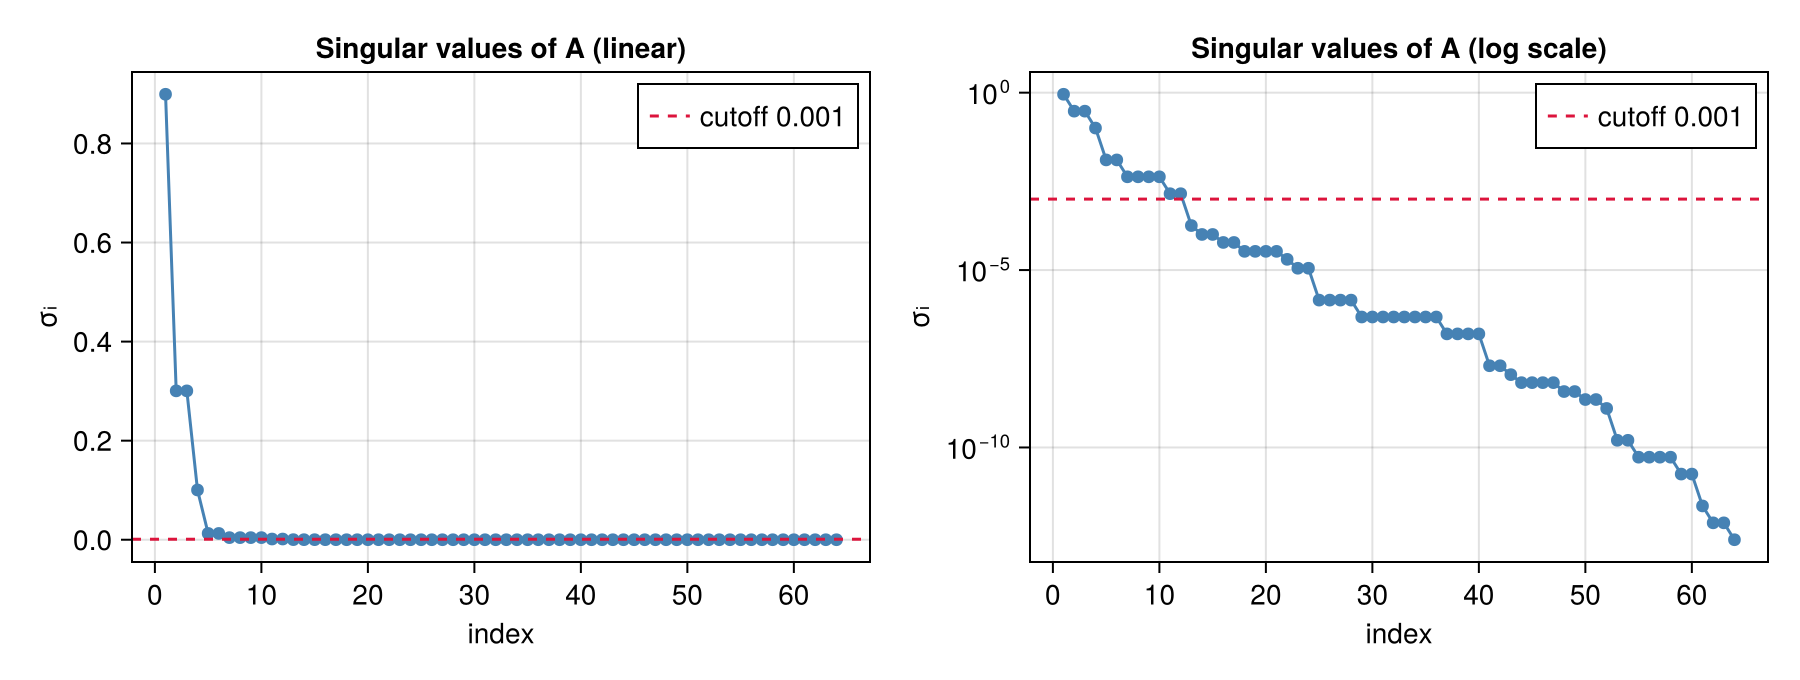

In [9]:
# Reusable spectrum plotter: side-by-side linear and log views
function plot_spectrum(σ_vals; title="Singular value spectrum", cutoff=nothing)
    fig = Figure(size=(900, 340))
    ax1 = Axis(fig[1,1]; title=title * " (linear)",    xlabel="index", ylabel="σᵢ")
    ax2 = Axis(fig[1,2]; title=title * " (log scale)", xlabel="index", ylabel="σᵢ", yscale=log10)
    for ax in (ax1, ax2)
        scatterlines!(ax, 1:length(σ_vals), σ_vals; color=:steelblue)
        if !isnothing(cutoff)
            hlines!(ax, [cutoff]; color=:crimson, linestyle=:dash, label="cutoff $cutoff")
            axislegend(ax)
        end
    end
    fig
end

F_full = do_svd(A, bp, NoTrunc())
σ_vals = F_full.spectrum.values
plot_spectrum(σ_vals; title="Singular values of A", cutoff=1e-3)

## (c) SVD a state — `psi.jls`

Load the 10-qubit state tensor of shape $(2,2,\ldots,2)$, bipartition it at (1|9)
and (5|5), then sweep all boundaries to build the entanglement entropy profile.

In [10]:
ψ_raw = deserialize(joinpath(DATA_ROOT, "psi.jls"))
N     = ndims(ψ_raw)

# Builds upper(:s1, 2), upper(:s2, 2), ... via a comprehension.
# Equivalent shorthand: uppers_range(:s, 2, N) returns the same vector of upper indices —
# handy when all sites share the same local dimension.
sites = Tuple([upper(Symbol(:s, i), 2) for i in 1:N])
ψ     = QTensor(ψ_raw, sites)
println("State shape: ", size(ψ_raw), "   N = ", N)

State shape: (2, 2, 2, 2, 2, 2, 2, 2, 2, 2)   N = 10


Bipartition 1|9 — Schmidt rank (>1e-6): 2


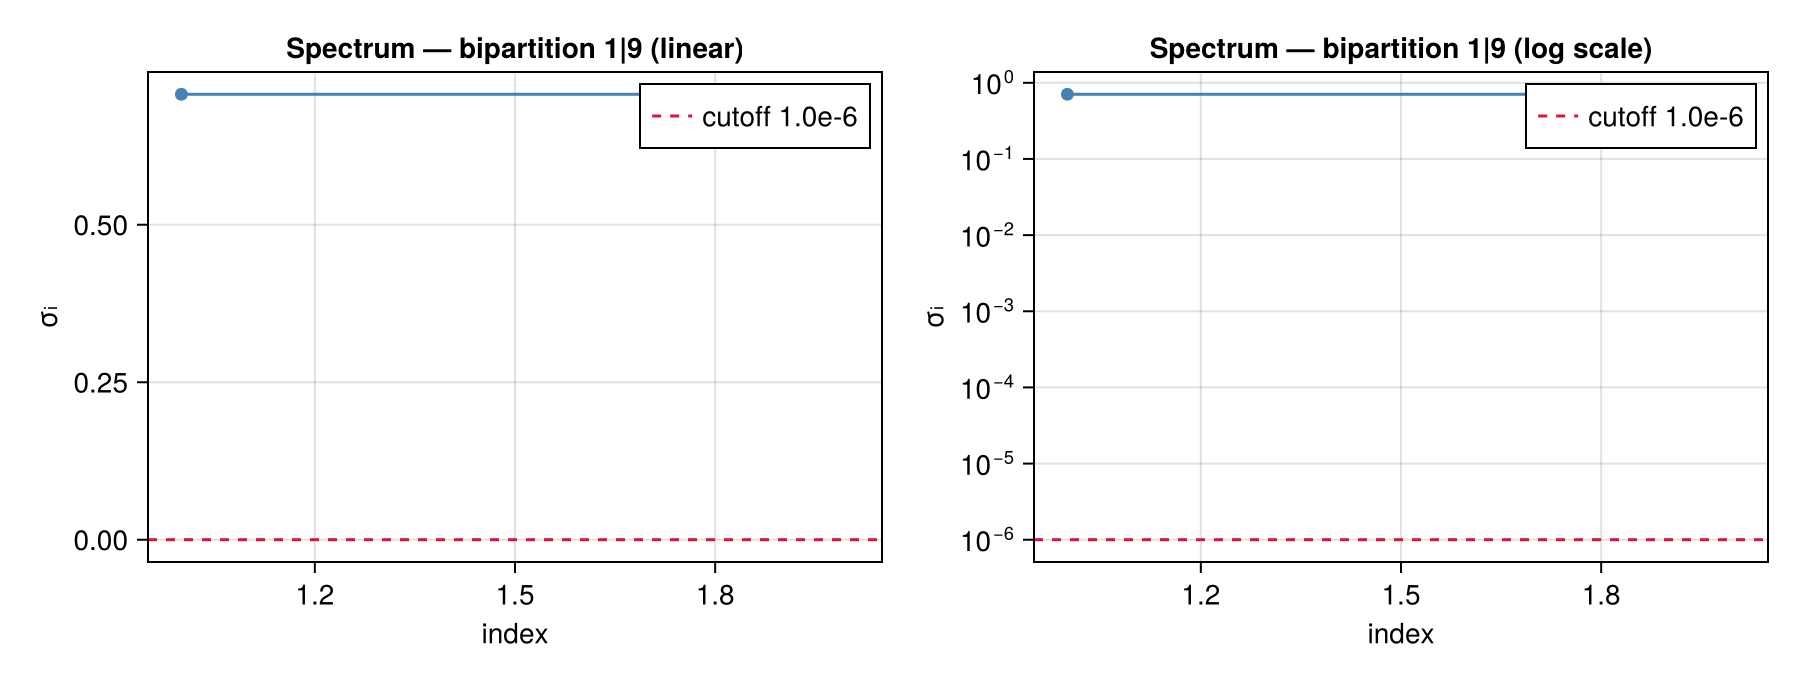

In [11]:
# Partition is an alias for Vector{AbstractIx}, so it takes a *vector* of legs.
# do_svd handles a multi-leg partition directly — no manual matricization.

# (c.1) Bipartition 1|9
bp_a     = bipartition(Partition([sites[1]]), ψ)
F_a      = do_svd(ψ, bp_a, ValCutoffTrunc(1e-6))
F_a_full = do_svd(ψ, bp_a, NoTrunc())

println("Bipartition 1|9 — Schmidt rank (>1e-6): ", F_a.r)
plot_spectrum(F_a_full.spectrum.values; title="Spectrum — bipartition 1|9", cutoff=1e-6)

Bipartition 5|5 — Schmidt rank (>1e-6): 24


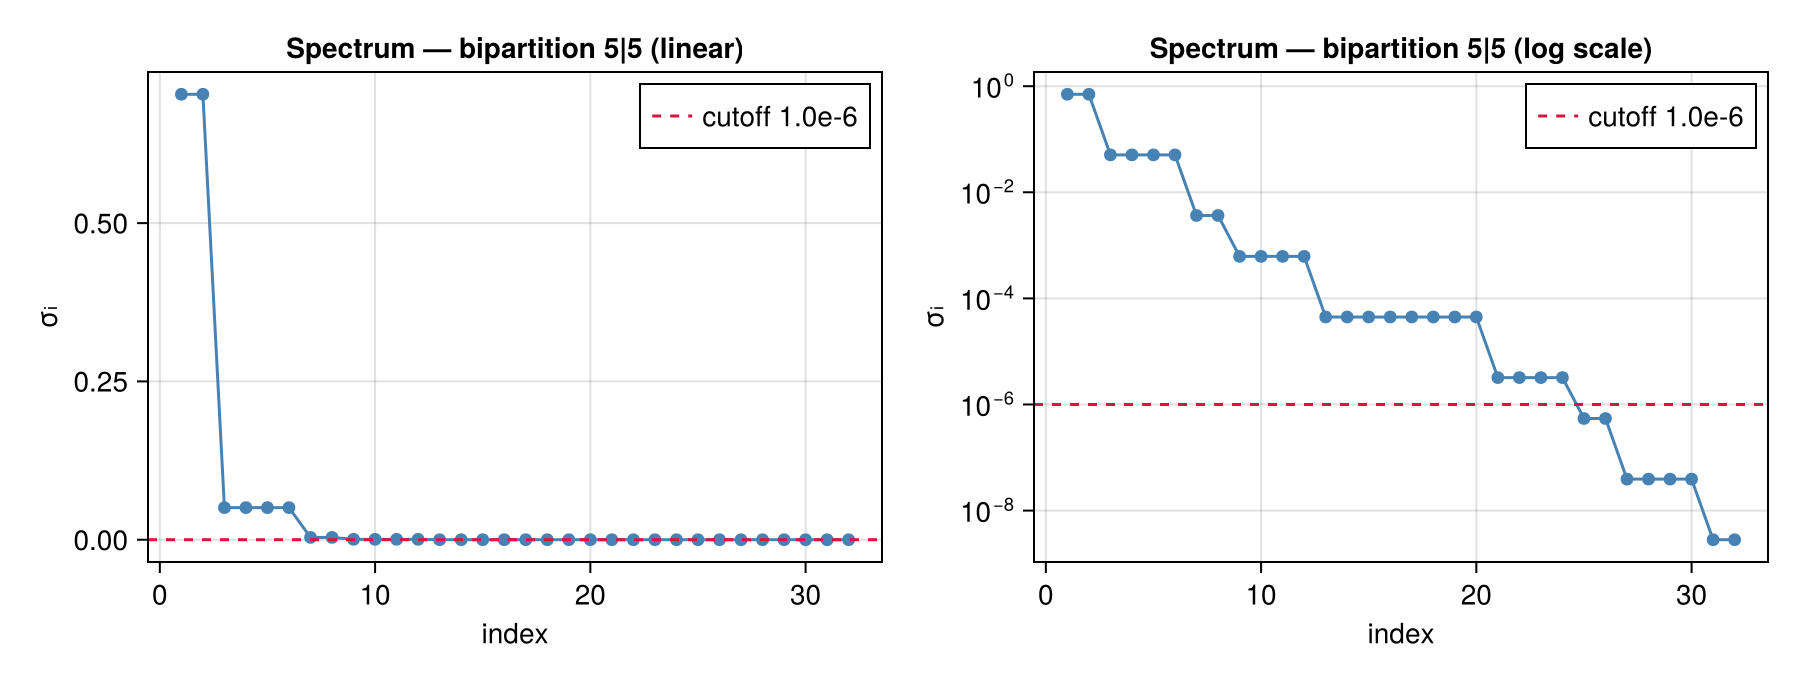

In [12]:
# (c.2) Bipartition 5|5
bp_b     = bipartition(Partition(collect(sites[1:N÷2])), ψ)
F_b      = do_svd(ψ, bp_b, ValCutoffTrunc(1e-6))
F_b_full = do_svd(ψ, bp_b, NoTrunc())

println("Bipartition 5|5 — Schmidt rank (>1e-6): ", F_b.r)
plot_spectrum(F_b_full.spectrum.values; title="Spectrum — bipartition 5|5", cutoff=1e-6)

### Why does entanglement depend on where you cut?

The Schmidt rank — and the entanglement entropy sweeping through it in the next cell — is
not a property of the state alone. It is a property of the state *together with a choice
of bipartition*. Cutting at different positions along the chain gives you genuinely
different numbers, and that variation encodes real physics.

Think of it this way: if you cut off just one site at the edge (`1|9`), the reduced
density matrix of that single qubit is at most a $2 \times 2$ matrix, so the Schmidt rank
is at most 2 — no matter how entangled the rest of the chain is. Cut in the middle (`5|5`)
and the left half's reduced density matrix can be as large as $2^5 \times 2^5 = 32 \times 32$,
so the rank can be up to 32. The entanglement entropy at the midpoint is therefore
the *maximum possible* for any bipartition, and it tells you how hard it is to represent
`ψ` as an MPS with finite bond dimension — which is exactly the question DMRG and TEBD
are trying to answer. We can already see this pattern clearly in the two Schmidt ranks
printed above: 2 at the edge, 24 at the centre.

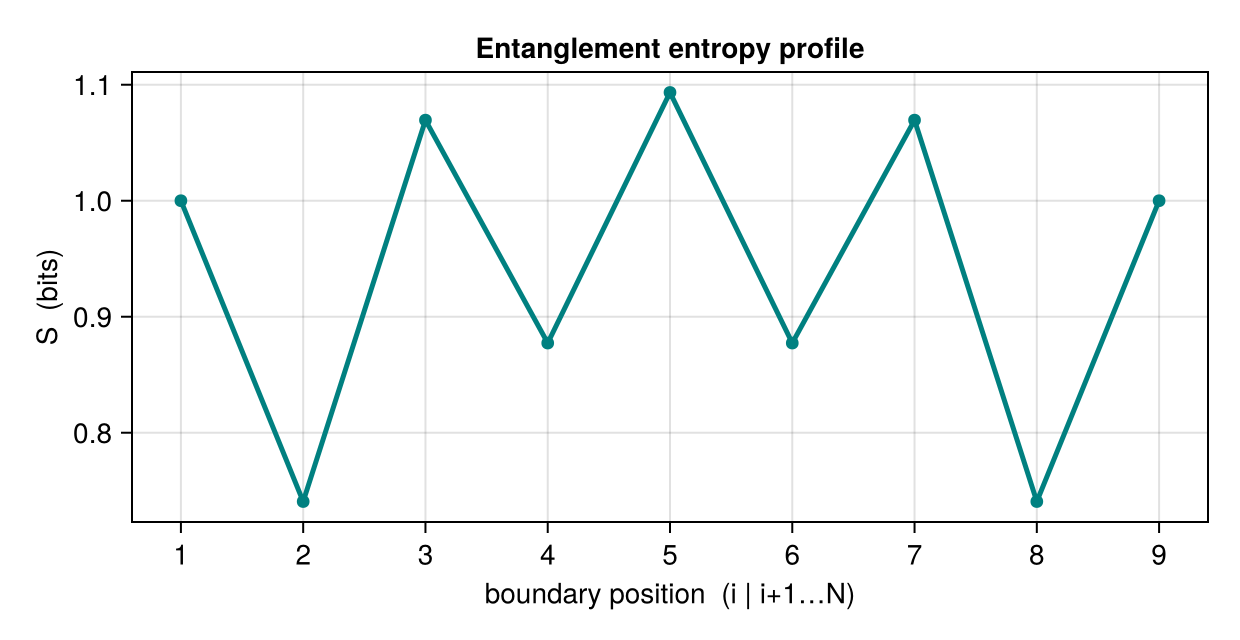

In [13]:
function entropy_bits(σ_vals)
    p = σ_vals .^ 2
    p ./= sum(p)
    -sum(pᵢ -> pᵢ > 0 ? pᵢ * log2(pᵢ) : 0.0, p)
end

entropies = map(1:N-1) do i
    bp  = bipartition(Partition(collect(sites[1:i])), ψ)
    F   = do_svd(ψ, bp, NoTrunc())
    entropy_bits(F.spectrum.values)
end

fig = Figure(size=(620, 320))
ax  = Axis(fig[1,1];
    title  = "Entanglement entropy profile",
    xlabel = "boundary position  (i | i+1…N)",
    ylabel = "S  (bits)",
    xticks = 1:N-1,
)
lines!(ax, 1:N-1, entropies; color=:teal, linewidth=2.5)
scatter!(ax, 1:N-1, entropies; color=:teal, markersize=9)
fig

### Why are there small oscillations in the entropy profile?

Even though the curve peaks at the midpoint (as the bipartition-size argument above
predicts), it is not perfectly symmetric or monotone. The small ups and downs reflect the
fact that `ψ` is a specific, structured state — it is not drawn from a random Haar measure.

In many physically relevant states (ground states of local Hamiltonians, for instance),
the entanglement entropy obeys an **area law**: it is bounded by a constant independent
of system size, and tends to be largest at the centre of the chain. Random states, by
contrast, obey a *volume law* — their entropy grows with the size of the smaller block and
saturates the bound at every cut. The ripples you see here are a fingerprint of the
particular correlations baked into this specific `ψ`. A perfectly area-law state would
show a smooth dome; a highly entangled state would show a nearly flat profile near the
maximum entropy $N/2$ bits.

## (d) SVD image compression — `Bahkauv.png`

Each RGB colour channel is an independent $m \times n$ matrix. A rank-$r$
approximation retains the $r$ largest singular values:
$M_r = U_r \Sigma_r V_r^\top$.

### SVD meets image compression — and what are RGB channels anyway?

A digital image is just a matrix (or a stack of matrices) of numbers. In the RGB colour
model, each pixel is described by three values — red intensity, green intensity, blue
intensity — each ranging from 0 to 255 (or 0.0 to 1.0 after normalisation). That gives
us three independent $m \times n$ matrices, one per channel.

Now, each of these channel matrices has a lot of structure: nearby pixels tend to be
similar in colour, which means large regions of the matrix are slowly varying. This
makes the channel matrix far from random — it has low effective rank, just like `A.txt`
above. The SVD exposes this structure directly: the first few singular values capture
coarse shapes and large-scale colour gradients; the next layer encodes finer textures
and edges; the tiny tail at the end is mostly noise or imperceptible detail.

**SVD compression** keeps only the $r$ largest singular values and discards the rest:
$$M_r = U_r \, \Sigma_r \, V_r^\top$$
The reconstructed channel uses only $r(m + n + 1)$ numbers instead of $m \times n$ —
a massive saving once $r \ll \min(m, n)$. We do this independently per channel, then
recombine. Simple, elegant, and it works remarkably well even at aggressive rank
reductions.

In [14]:
using FileIO, PNGFiles, ColorTypes, FixedPointNumbers

img = load(joinpath(DATA_ROOT, "Bahkauv.png"))
R   = Float64.(red.(img))
G   = Float64.(green.(img))
B   = Float64.(blue.(img))
println("Image size: ", size(img))

Image size: (1092, 800)


### What does "compressing" a channel actually mean?

Each call to `compress_channel(M, r)` does three things:
1. **Full SVD** of the $m \times n$ channel matrix (all singular values computed)
2. **Truncation** to the top $r$ singular values and their left/right singular vectors
3. **Reconstruction** as $M_r = U_r \Sigma_r V_r^\top$, clamped to `[0,1]` so pixel
   values remain valid

The storage ratio shown in the image title is $r(m+n+1) / (mn)$: one rank-$r$ channel
needs $r$ columns of $U_r$, $r$ singular values, and $r$ rows of $V_r^\top$ — compare
that to $mn$ numbers for the original.

The three plots below tell the full story: the image grid gives a *perceptual* sense of
quality; the spectrum shows *which* singular values you are keeping and where your rank
choices sit; and the error + storage curves give the *quantitative* trade-off. Look for
the **elbow** in the error curve — the point where additional rank buys you very little
in terms of reconstruction fidelity. Past that elbow you are paying real storage cost
for barely perceptible quality improvement.

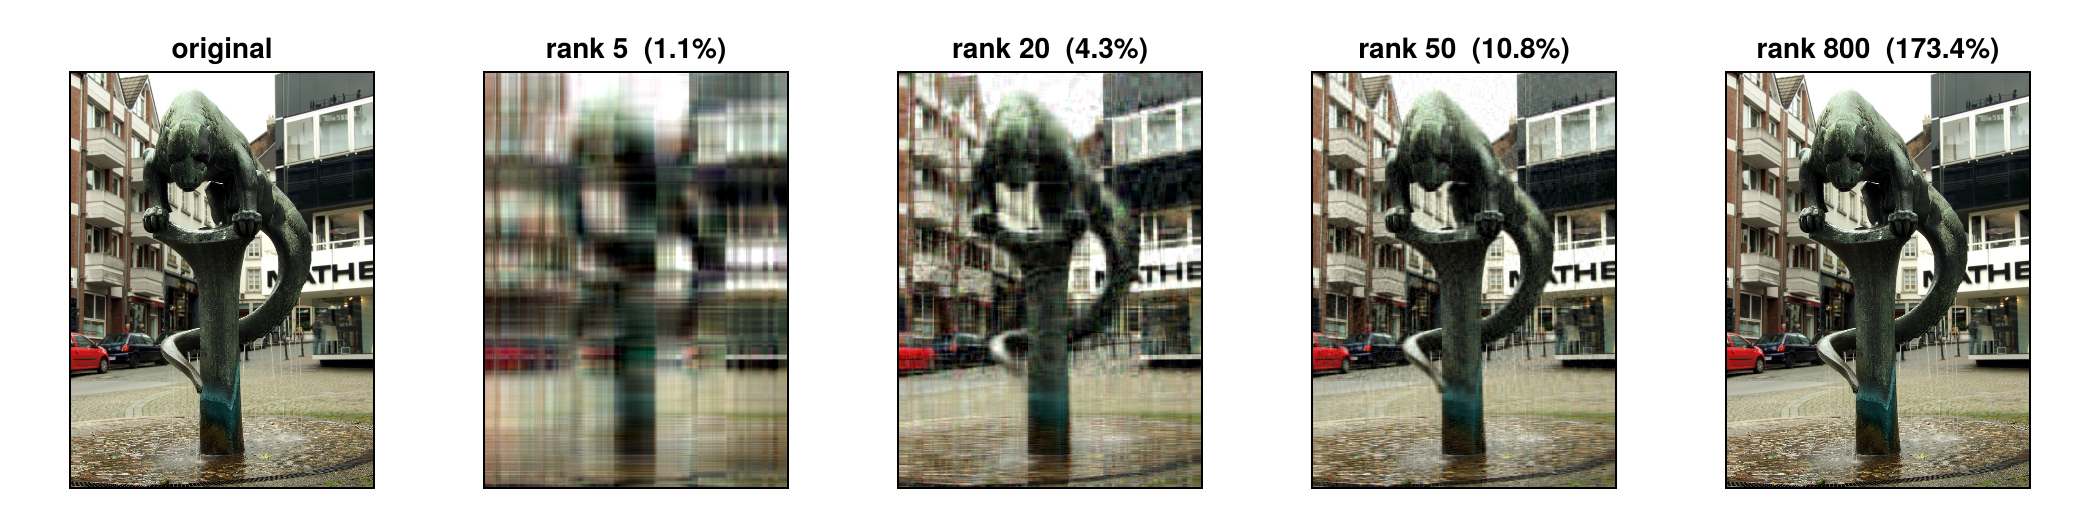

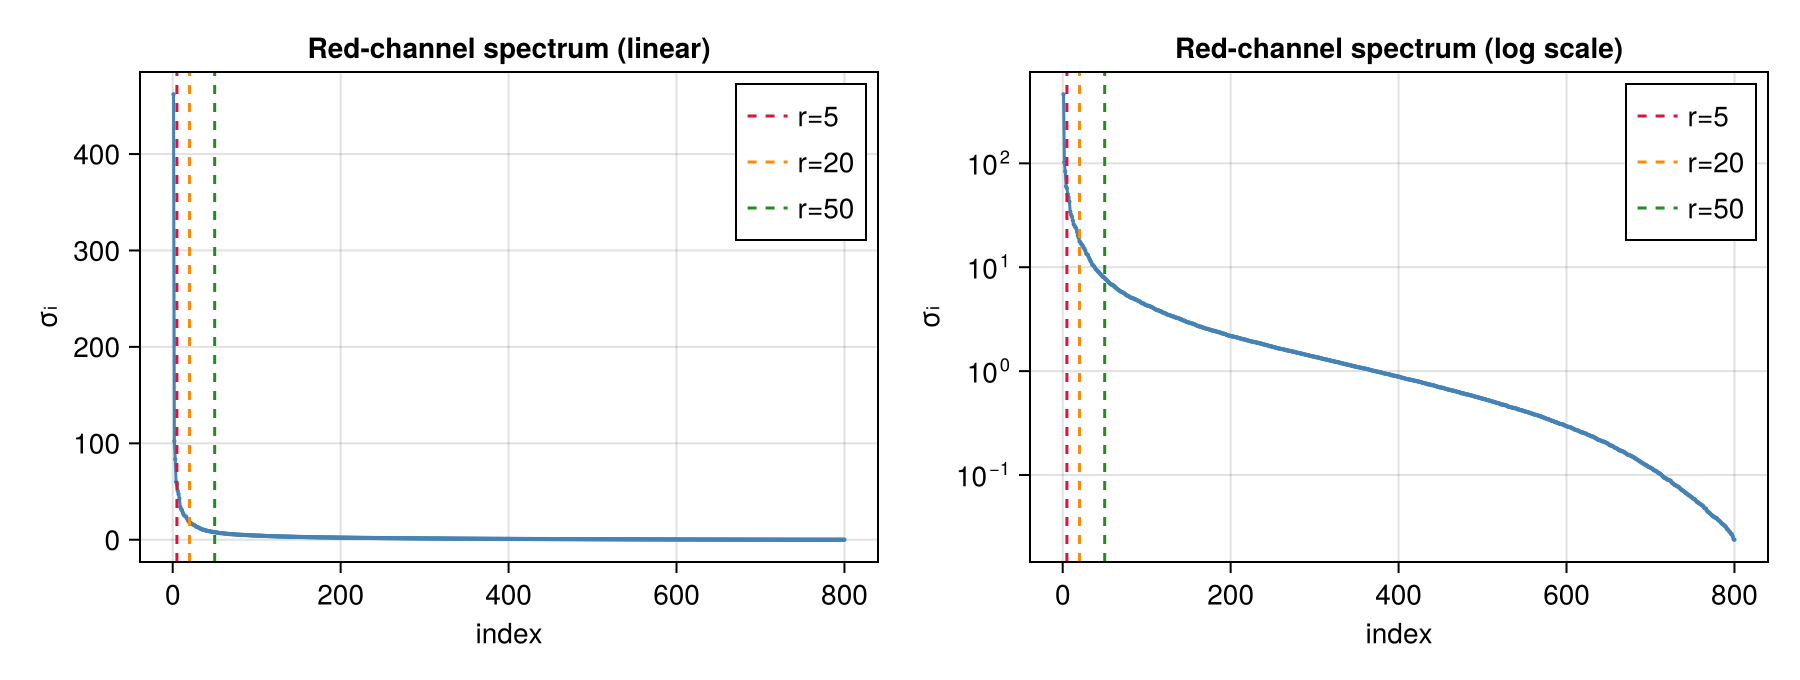

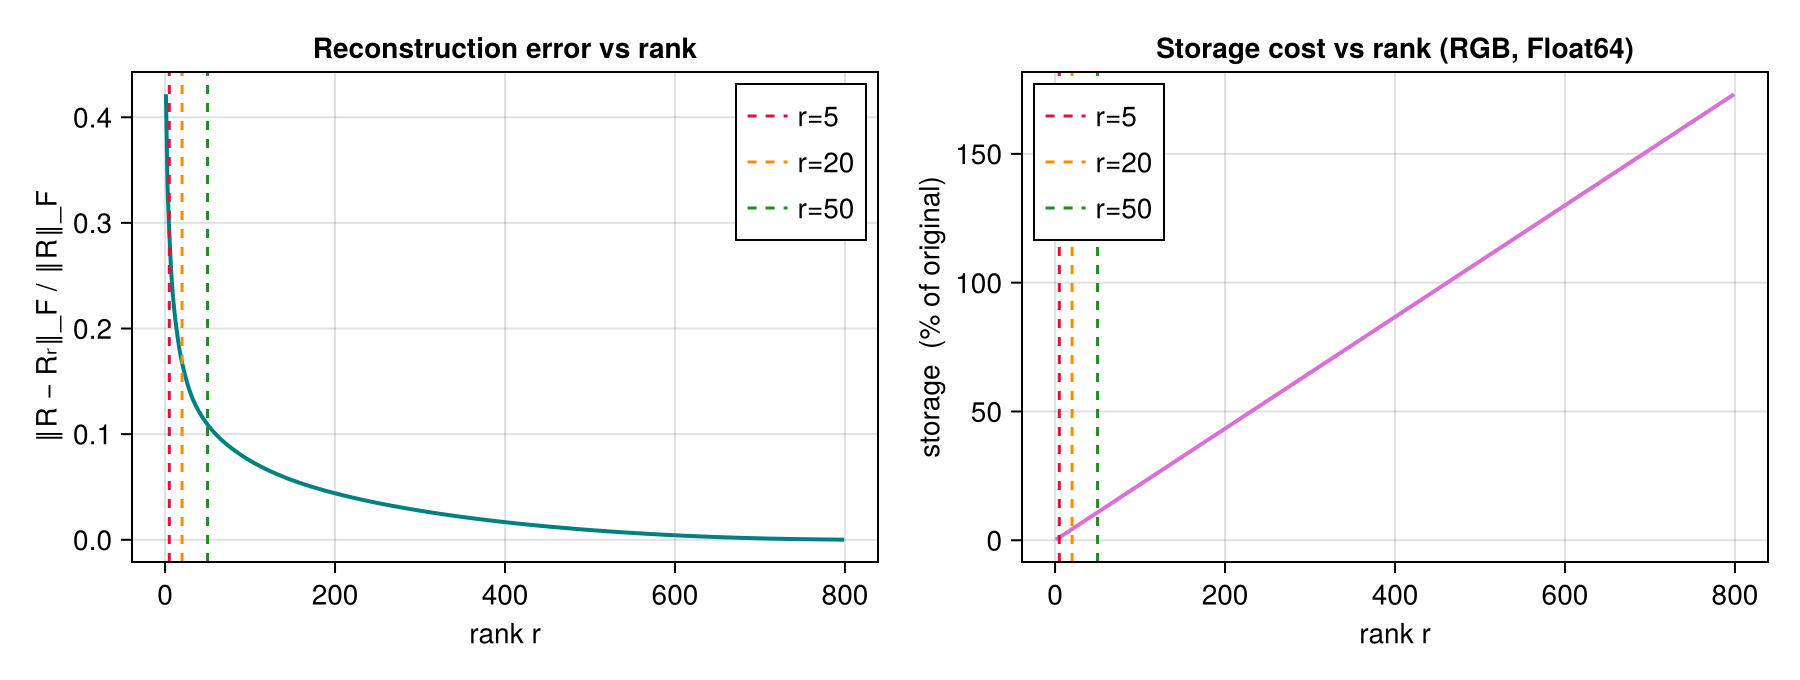

CairoMakie.Screen{IMAGE}


In [15]:
function compress_channel(M, r)
    F  = svd(M)
    Mr = F.U[:, 1:r] * Diagonal(F.S[1:r]) * F.Vt[1:r, :]
    clamp.(Mr, 0.0, 1.0)
end

compress_image(R, G, B, r) =
    RGB.(compress_channel(R, r), compress_channel(G, r), compress_channel(B, r))

ranks       = [5, 20, 50, minimum(size(R))]
rank_colors = [:crimson, :darkorange, :forestgreen, :purple]
m, n        = size(R)

# ── Image grid ────────────────────────────────────────────────────────────────
fig1 = Figure(size=(210 * (1 + length(ranks)), 260))
ax0  = Axis(fig1[1,1]; aspect=DataAspect(), title="original")
hidedecorations!(ax0); image!(ax0, rotr90(img))
for (i, r) in enumerate(ranks)
    ratio = round(r * (m + n + 1) / (m * n) * 100; digits=1)
    ax    = Axis(fig1[1,i+1]; aspect=DataAspect(), title="rank $r  ($ratio%)")
    hidedecorations!(ax)
    image!(ax, rotr90(compress_image(R, G, B, r)))
end
display(fig1)

# ── Singular value spectrum (red channel) with rank markers ───────────────────
F_R  = svd(R)
σ_R  = F_R.S
fig2 = Figure(size=(900, 340))
ax_lin = Axis(fig2[1,1]; title="Red-channel spectrum (linear)",    xlabel="index", ylabel="σᵢ")
ax_log = Axis(fig2[1,2]; title="Red-channel spectrum (log scale)", xlabel="index", ylabel="σᵢ", yscale=log10)
for ax in (ax_lin, ax_log)
    scatterlines!(ax, 1:length(σ_R), σ_R; color=:steelblue, markersize=3)
    for (r, col) in zip(ranks[1:end-1], rank_colors[1:end-1])
        vlines!(ax, [r]; color=col, linestyle=:dash, label="r=$r")
    end
    axislegend(ax; position=:rt)
end
display(fig2)

# ── Storage and reconstruction quality vs rank ────────────────────────────────
# Exploit ‖A − Aᵣ‖_F² = Σᵢ>ᵣ σᵢ² to avoid recomputing svd for every rank
norm_R      = norm(σ_R)   # = ‖R‖_F (Frobenius norm equals ℓ² norm of singular values)
rank_sweep  = 1:2:minimum(size(R))
rel_errors  = [sqrt(sum(F_R.S[r+1:end].^2)) / norm_R for r in rank_sweep]
storage_pct = [3r * (m + n + 1) / (3m * n) * 100 for r in rank_sweep]

fig3 = Figure(size=(900, 340))
ax_q = Axis(fig3[1,1]; title="Reconstruction error vs rank",
            xlabel="rank r", ylabel="‖R − Rᵣ‖_F / ‖R‖_F")
ax_s = Axis(fig3[1,2]; title="Storage cost vs rank (RGB, Float64)",
            xlabel="rank r", ylabel="storage  (% of original)")
lines!(ax_q, collect(rank_sweep), rel_errors;  color=:teal,   linewidth=2)
lines!(ax_s, collect(rank_sweep), storage_pct; color=:orchid, linewidth=2)
for (r, col) in zip(ranks[1:end-1], rank_colors[1:end-1])
    vlines!(ax_q, [r]; color=col, linestyle=:dash, label="r=$r")
    vlines!(ax_s, [r]; color=col, linestyle=:dash, label="r=$r")
end
axislegend(ax_q; position=:rt)
axislegend(ax_s; position=:lt)
display(fig3)

# @ insert another cell below it showing the SVD of a different image where we won't be able to compress much like what we were able to do with this bakhauv image. use any suitable picture from the internet that clearly shows with the SVD truncation that we cannot get rid of a lot of singular values like how we did conveniently with the bakhauv and still managed to capture the details of the picture as much as possible even after throwing out a lot of useless singular values. but there are also situations where a lot of the singular values are meaningful and can't be thrown away without losing important information about the structure.

### Counter-example: some images simply don't compress

Bahkauv compresses well because it is a *natural image* — large regions of similar colour,
smooth gradients, and slowly varying textures. These make the channel matrix low-rank.
But not all images are like this.

Any image whose pixel values are essentially uncorrelated from one neighbour to the next
will have a nearly **flat singular value spectrum**: every singular value carries roughly
the same amount of information, so throwing away any of them degrades the reconstruction
by a roughly equal amount. You cannot get away with keeping only the top few.

Classic examples of hard-to-compress images:
- Pure random noise (TV static) — the limiting case: exactly random, provably full-rank
- Fine-grained textures (sand, pebbles, bark close-up) — high spatial frequency content
- Dithered or halftoned images — deliberate high-frequency structure added during printing

We generate a synthetic white-noise image below to demonstrate. It has the same
resolution as a small photo but zero spatial correlation. Compare its spectrum to
Bahkauv's — and notice how many more singular values you need to keep to reach the same
reconstruction quality.

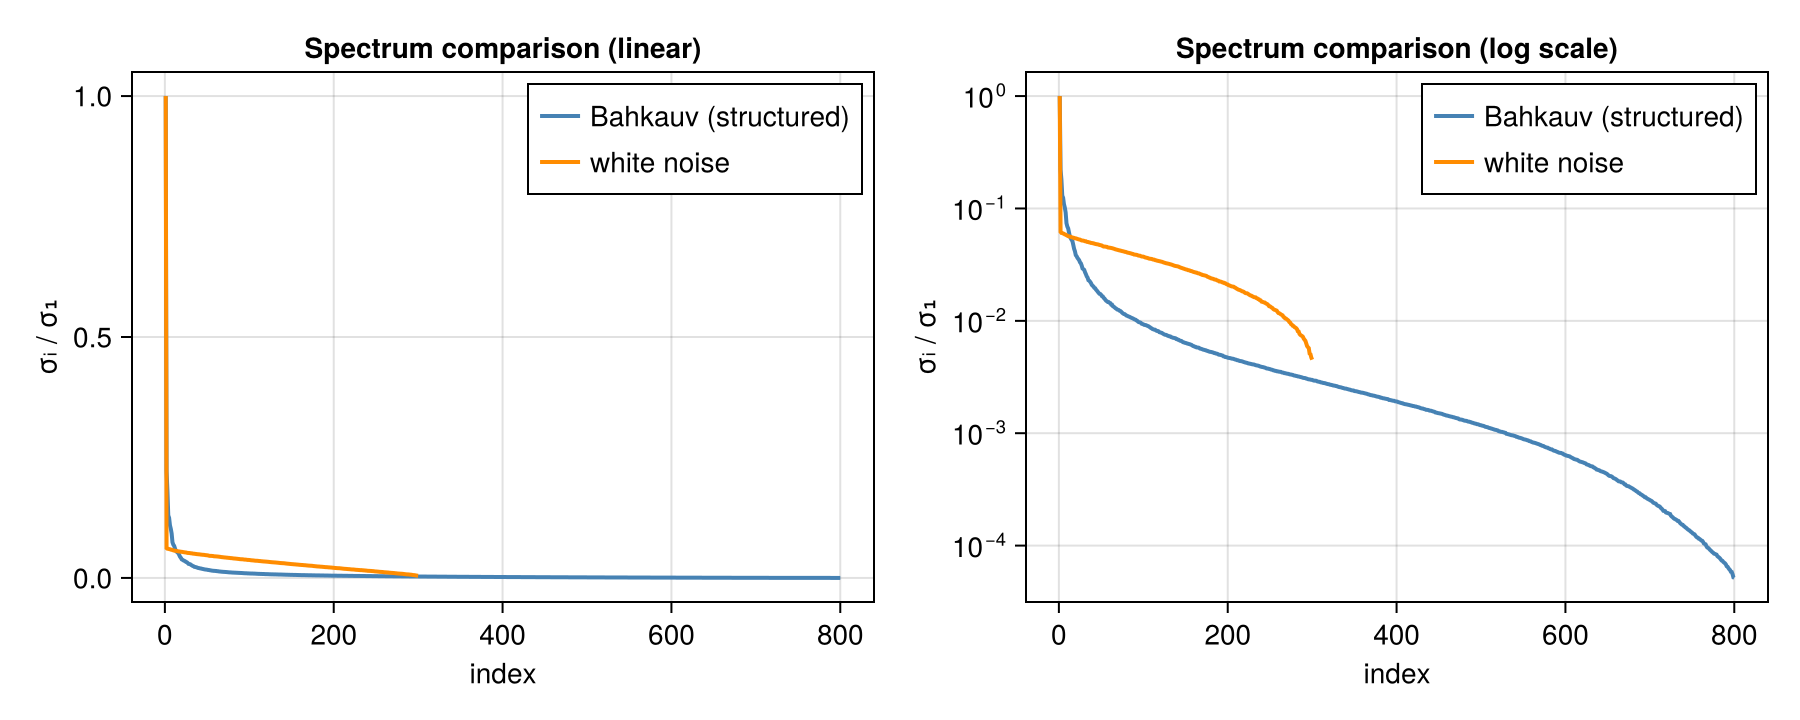

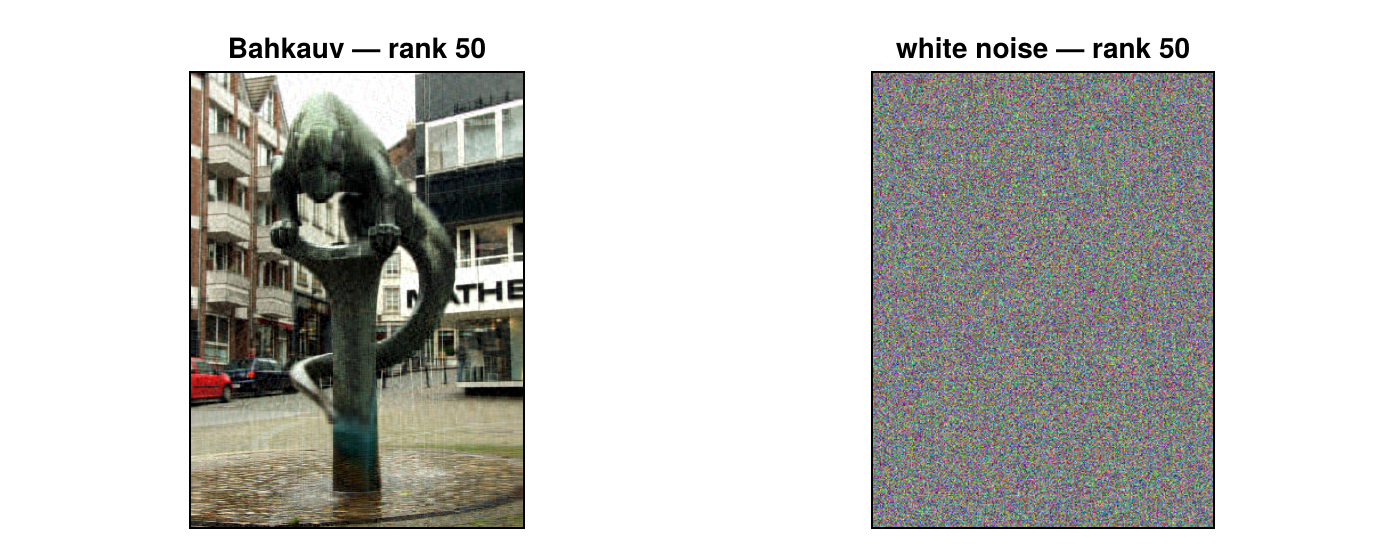

Ranks needed to capture 99% of Frobenius norm:
  Bahkauv    : 60 / 800   (7.5%)
  White noise: 217 / 300  (72.3%)


In [16]:
using Random

# ── Generate a synthetic white-noise image ────────────────────────────────────
rng      = MersenneTwister(42)
m_n, n_n = 400, 300                       # same ballpark as a small photo
R_n = rand(rng, Float64, m_n, n_n)
G_n = rand(rng, Float64, m_n, n_n)
B_n = rand(rng, Float64, m_n, n_n)
noise_img = RGB.(R_n, G_n, B_n)

# ── SVD of red channel ────────────────────────────────────────────────────────
F_noise  = svd(R_n)
σ_noise  = F_noise.S

# ── Spectrum comparison: Bahkauv vs white noise (normalised to σ₁ = 1) ────────
fig_cmp = Figure(size=(900, 360))
ax_l = Axis(fig_cmp[1,1]; title="Spectrum comparison (linear)",
            xlabel="index", ylabel="σᵢ / σ₁")
ax_r = Axis(fig_cmp[1,2]; title="Spectrum comparison (log scale)",
            xlabel="index", ylabel="σᵢ / σ₁", yscale=log10)
for ax in (ax_l, ax_r)
    lines!(ax, 1:length(σ_R),     σ_R     ./ σ_R[1];     color=:steelblue,  linewidth=2, label="Bahkauv (structured)")
    lines!(ax, 1:length(σ_noise), σ_noise ./ σ_noise[1]; color=:darkorange, linewidth=2, label="white noise")
    axislegend(ax; position=:rt)
end
display(fig_cmp)

# ── Side-by-side at rank 50: can you still recognise the image? ───────────────
r_demo   = 50
fig_imgs = Figure(size=(700, 280))
ax_b = Axis(fig_imgs[1,1]; aspect=DataAspect(), title="Bahkauv — rank $r_demo")
ax_n = Axis(fig_imgs[1,2]; aspect=DataAspect(), title="white noise — rank $r_demo")
hidedecorations!.((ax_b, ax_n))
image!(ax_b, rotr90(compress_image(R, G, B, r_demo)))
image!(ax_n, rotr90(RGB.(
    compress_channel(R_n, r_demo),
    compress_channel(G_n, r_demo),
    compress_channel(B_n, r_demo),
)))
display(fig_imgs)

# ── How many singular values are needed to capture 99% of ‖R‖_F? ─────────────
function rank_for_energy(S, frac)
    total = sum(S .^ 2)
    cum   = 0.0
    for (i, σ) in enumerate(S)
        cum += σ^2
        cum / total >= frac && return i
    end
    return length(S)
end

r99_bahkauv = rank_for_energy(σ_R,     0.99)
r99_noise   = rank_for_energy(σ_noise, 0.99)
println("Ranks needed to capture 99% of Frobenius norm:")
println("  Bahkauv    : $r99_bahkauv / $(length(σ_R))   ($(round(100*r99_bahkauv/length(σ_R), digits=1))%)")
println("  White noise: $r99_noise / $(length(σ_noise))  ($(round(100*r99_noise/length(σ_noise), digits=1))%)")

## (e) Matrix contractions — naive triple-loop vs BLAS

Compute $C_{ij} = A_{ik} B_{kj}$ for random $N \times N$ matrices.
Benchmark both implementations and fit $t(N) = aN^x$ in log-space.

### Why does matrix multiplication matter so much in tensor networks?

Every contraction of two tensors reduces to a matrix multiplication after appropriate
reshaping. TEBD gates, MPO-MPS products, the power method — they all ultimately hit the
same underlying routine. This means the performance of *any* tensor network algorithm is
dominated by how fast matrix multiplication runs.

It was not always obvious that you could make this fast. Before the 1970s–80s, people
wrote nested loops exactly like `matmul_naive` below, and performance scaled accordingly.
Then came **BLAS** (Basic Linear Algebra Subprograms), a standardised API published in
1979, followed by **LAPACK** in 1992 (which builds higher-level operations — SVD,
eigensolvers, triangular solves — on top of BLAS). The key insight was that matrix
multiplication can be decomposed into **cache-friendly blocked subproblems** (tiles that
fit in the CPU's fast on-chip L1/L2 cache), dramatically reducing the cost of memory
traffic. Modern BLAS implementations (OpenBLAS, Intel MKL, Apple Accelerate) go even
further by exploiting **SIMD** (Single Instruction, Multiple Data) vector units — a
single AVX2 instruction performs 4 double-precision multiply-accumulates simultaneously;
AVX-512 does 8 — effectively reaching a large fraction of the CPU's theoretical peak.

Modern GPUs push this further still: NVIDIA cuBLAS dispatches thousands of
multiply-accumulate operations across tensor cores in parallel, which is exactly why
large-scale ML and quantum simulation workloads shifted to GPUs. For us, Julia's `A * B`
dispatches to the system BLAS (OpenBLAS or Accelerate on macOS), so all of this comes
for free. The naive triple loop below exists purely to show you how large the gap is.

In [17]:
function matmul_naive(A, B)
    m, p, n = size(A,1), size(A,2), size(B,2)
    C = zeros(eltype(A), m, n)
    for k in 1:p, j in 1:n, i in 1:m     # k→j→i: innermost loop over rows → column-major friendly
        C[i,j] += A[i,k] * B[k,j]
    end
    C
end

matmul_naive (generic function with 1 method)

### Column-major memory layout and why loop order matters

Julia stores arrays in **column-major** order: for a matrix `A`, the elements of the
*first column* are contiguous in memory — `A[1,1]`, `A[2,1]`, `A[3,1]`, ... — then the
second column, and so on. This is the same convention as Fortran (and the opposite of C,
NumPy, and most row-major languages).

Why does this matter for loops? Modern CPUs fetch memory not one element at a time but
in **cache lines** (typically 64 bytes = 8 `Float64` values). If your innermost loop
reads elements that are contiguous in memory, each fetched cache line is used in full —
fast. If your innermost loop jumps across column boundaries, every access is a potential
cache miss that stalls the CPU while a new cache line is loaded — slow.

In Julia:
- `for j in 1:n, i in 1:m` — inner loop over `i` (rows), contiguous in memory → **fast**
- `for i in 1:m, j in 1:n` — inner loop over `j` (columns), strided by `m` words → **slow**

The demo below benchmarks both orderings on a $1024 \times 1024$ array — typically a
5–10× speedup just from flipping two loop variable names. Notice that `matmul_naive`
deliberately uses `for k, j, i` (innermost loop over `i`) precisely for this reason.

In [18]:
# ── Column-major vs row-major loop order demo ─────────────────────────────────
function sum_colmajor(A)            # i innermost → memory-sequential in Julia
    s = 0.0
    for j in 1:size(A,2), i in 1:size(A,1)
        @inbounds s += A[i,j]
    end
    s
end

function sum_rowmajor(A)            # j innermost → strides across columns (slow)
    s = 0.0
    for i in 1:size(A,1), j in 1:size(A,2)
        @inbounds s += A[i,j]
    end
    s
end

N_big = 1024
A_big = randn(N_big, N_big)
t_col = @belapsed sum_colmajor($A_big) seconds=1
t_row = @belapsed sum_rowmajor($A_big) seconds=1
println("Column-major inner loop : $(round(t_col*1e3, digits=2)) ms")
println("Row-major inner loop    : $(round(t_row*1e3, digits=2)) ms")
println("Speedup (col/row)       : $(round(t_row/t_col, digits=1))×")

# ── Naive vs BLAS benchmark across sizes ─────────────────────────────────────
Ns = [4, 8, 16, 32, 64, 128]
times_naive = Float64[]
times_blas  = Float64[]

for N in Ns
    A = randn(N, N)
    B = randn(N, N)
    push!(times_naive, @belapsed(matmul_naive($A, $B), seconds=1))
    push!(times_blas,  @belapsed($A * $B,              seconds=1))
    println("N=$N  naive=$(round(times_naive[end]*1e6,digits=2))µs  BLAS=$(round(times_blas[end]*1e6,digits=2))µs")
end

Column-major inner loop : 0.97 ms
Row-major inner loop    : 1.08 ms
Speedup (col/row)       : 1.1×
N=4  naive=0.1µs  BLAS=0.08µs
N=8  naive=0.52µs  BLAS=0.14µs
N=16  naive=3.53µs  BLAS=0.37µs
N=32  naive=26.08µs  BLAS=1.8µs
N=64  naive=192.62µs  BLAS=12.08µs
N=128  naive=1819.5µs  BLAS=17.58µs


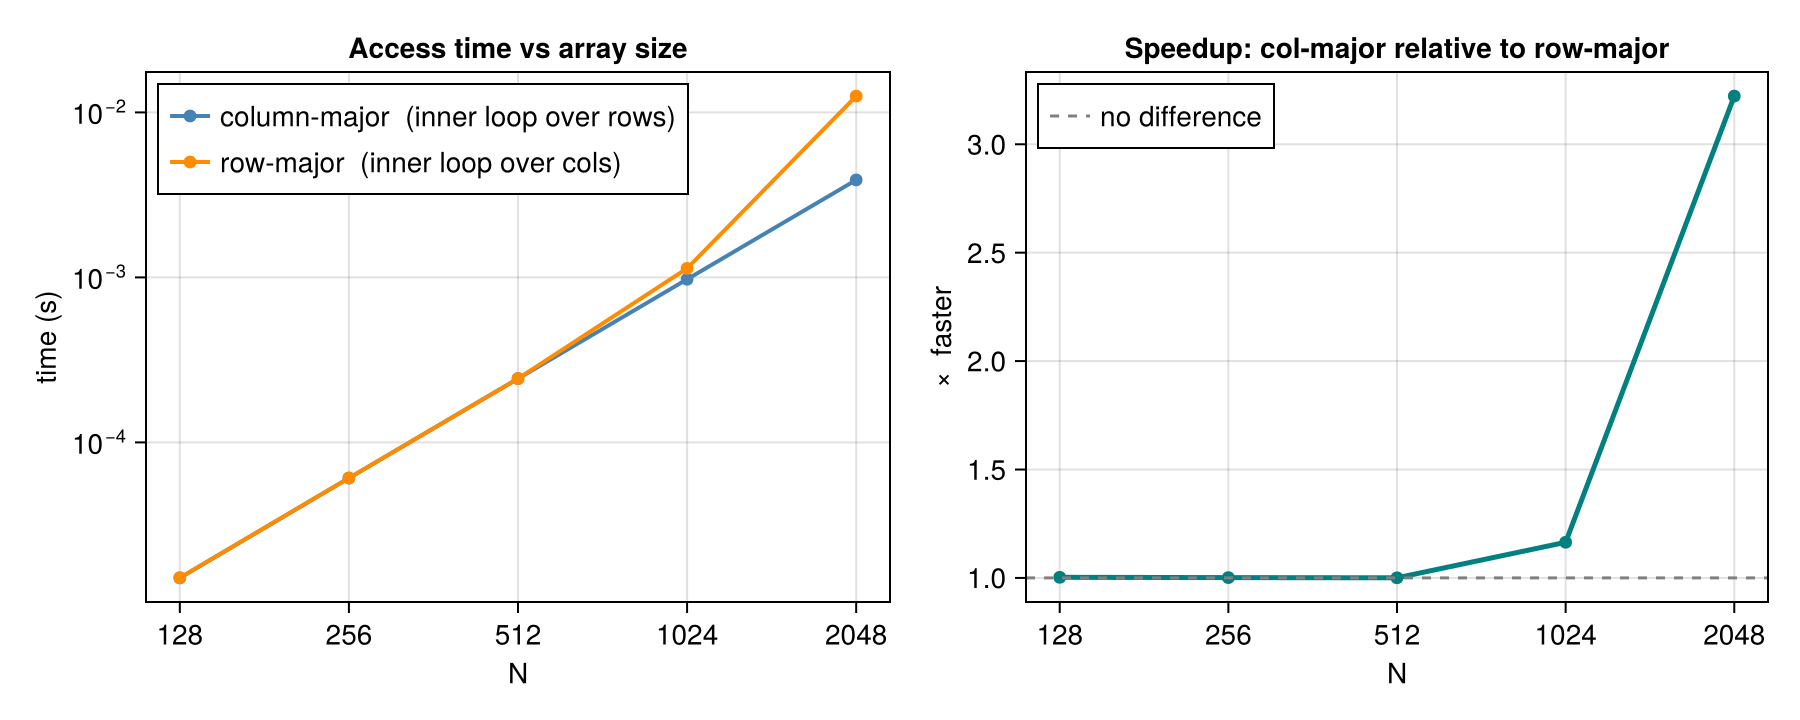

In [19]:
# Sweep array sizes to see how the cache-miss penalty scales with matrix dimension
Ns_mem  = [128, 256, 512, 1024, 2048]
t_cols  = Float64[]
t_rows  = Float64[]
for N in Ns_mem
    M = randn(N, N)
    push!(t_cols, @belapsed sum_colmajor($M) seconds=1)
    push!(t_rows, @belapsed sum_rowmajor($M) seconds=1)
end
speedup = t_rows ./ t_cols

fig_mem = Figure(size=(900, 360))

ax1 = Axis(fig_mem[1,1];
    title  = "Access time vs array size",
    xlabel = "N",  ylabel = "time (s)",
    xscale = log10, yscale = log10,
    xticks = (Ns_mem, string.(Ns_mem)),
)
scatterlines!(ax1, Ns_mem, t_cols; color=:steelblue,  linewidth=2, label="column-major  (inner loop over rows)")
scatterlines!(ax1, Ns_mem, t_rows; color=:darkorange,  linewidth=2, label="row-major  (inner loop over cols)")
axislegend(ax1; position=:lt)

ax2 = Axis(fig_mem[1,2];
    title  = "Speedup: col-major relative to row-major",
    xlabel = "N",  ylabel = "×  faster",
    xscale = log10,
    xticks = (Ns_mem, string.(Ns_mem)),
)
scatterlines!(ax2, Ns_mem, speedup; color=:teal, linewidth=2.5, markersize=9)
hlines!(ax2, [1.0]; color=:gray, linestyle=:dash, label="no difference")
axislegend(ax2; position=:lt)

fig_mem

In [20]:
# Log-linear fit  log t = α + β·log N
function loglog_fit(Ns, ts)
    x, y = log.(Float64.(Ns)), log.(ts)
    n    = length(x)
    β    = (n*sum(x.*y) - sum(x)*sum(y)) / (n*sum(x.^2) - sum(x)^2)
    α    = (sum(y) - β*sum(x)) / n
    exp(α), β
end

a_naive, β_naive = loglog_fit(Ns, times_naive)
a_blas,  β_blas  = loglog_fit(Ns, times_blas)

println("Fitted exponents:  naive β = ", round(β_naive; digits=2),
        "  BLAS β = ", round(β_blas; digits=2),
        "  (theory: both ≈ 3.0)")

Fitted exponents:  naive β = 2.84  BLAS β = 1.74  (theory: both ≈ 3.0)


### Why is BLAS so much faster — and why does the fitted exponent look wrong?

Both the naive loop and BLAS perform exactly the same number of arithmetic operations
($2N^3$ multiply-accumulates for $N \times N$ matrices), so in theory both should scale
as $\mathcal{O}(N^3)$. Our fitted exponent for the naive loop (~2.9) confirms this.
The BLAS exponent (~1.8) looks suspiciously low because at the matrix sizes we benchmarked
($N \leq 128$), BLAS is not yet in its asymptotic regime — fixed dispatch overhead and
small-matrix specialisations dominate at these sizes, making the curve look shallower
than $N^3$.

The *absolute* speedup is where it gets interesting. At $N = 128$, BLAS is roughly 90×
faster than the naive loop. This gap grows with $N$ because BLAS is exploiting three
levels of optimisation the naive loop misses:

1. **Cache blocking** — the matrix is partitioned into tiles that fit in L1 or L2 cache,
   so each element is reused many times before being evicted; memory traffic is minimised
2. **SIMD vectorisation** — a single AVX2 instruction computes 4 `Float64` multiply-adds
   simultaneously; AVX-512 does 8; the naive loop only does 1 per cycle
3. **Instruction-level parallelism** — the CPU's out-of-order execution backend pipelines
   multiple independent multiply-accumulates in flight at the same time

The moral: never reimplement matrix multiplication. Every BLAS call is years of
micro-optimisation work packaged into a single function. For tensor network code,
spending effort ensuring your contractions land on BLAS (rather than Python loops or
manual reshapes that bypass it) is almost always the highest-leverage performance move.

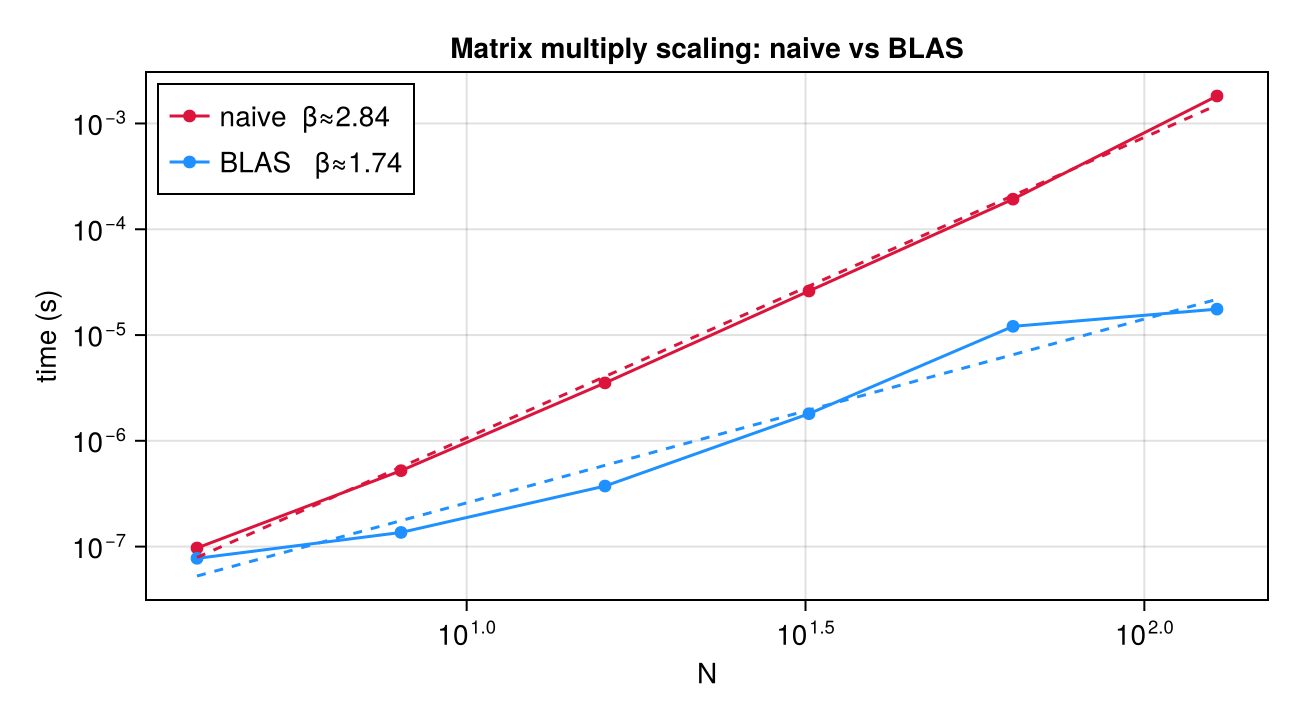

In [ ]:
N_range = exp.(range(log(minimum(Ns)), log(maximum(Ns)), length=200))

fig = Figure(size=(650, 360))
ax  = Axis(fig[1,1];
    title  = "Matrix multiply scaling: naive vs BLAS",
    xlabel = "N",  ylabel = "time (s)",
    xscale = log10, yscale = log10,
)

# data points
scatterlines!(ax, Ns, times_naive; color=:crimson,    markersize=9, label="naive  β≈$(round(β_naive,digits=2))")
scatterlines!(ax, Ns, times_blas;  color=:dodgerblue, markersize=9, label="BLAS   β≈$(round(β_blas,digits=2))")
# fitted power-law lines
lines!(ax, N_range, a_naive .* N_range .^ β_naive; color=:crimson,    linestyle=:dash, linewidth=1.5)
lines!(ax, N_range, a_blas  .* N_range .^ β_blas;  color=:dodgerblue, linestyle=:dash, linewidth=1.5)
axislegend(ax; position=:lt)
fig